<a href="https://colab.research.google.com/github/patelomniraj/ML-Projects/blob/main/AutomatedEDA_Tool_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task :


---


# **Build a reusable Python function/class DataProfiler that takes any dataframe.**



---


#**Auto-generates a full statistical summary report (per column: mean, median, std, skew, kurtosis, outlier flags using both Z-score and IQR methods) exports it as an HTML/PDF report.**





# Automated EDA Logic

---



In [7]:
import pandas as pd

df = pd.read_csv("Any .CSV File")


# Step 1 : Columns Separate
cols = df.select_dtypes(include=["number"])

# Empty List
report = []

# step 3 Loop in columns

for col in cols:

  series = df[col]

  # Mean , median , std
  col_mean = series.mean()
  col_median = series.median()
  col_std = series.std()


  # Calculate the shape - skew , kurtosis

  col_skew = series.skew()
  col_kurt = series.kurt()

  # IQR
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - (1.5*IQR)
  upper_bound = Q3 + (1.5*IQR)

  iqr_outliers = series[(series < lower_bound) | (series > upper_bound)]

  clean_df_iqr = df[~iqr_outliers]  # Clean from Outliers using IQR Method

  # Z score
  z_score = (series-col_mean)/col_std
  z_outliers = series[z_score.abs() > 3]

  clean_df_z_score = df[~z_outliers]  # Clean from Outliers using Z Score

  # Store everything in a Dictionary

  col_dict = {
      'Feature': col,
      'Mean': round(col_mean,2),
      'Median': round(col_median,2),
      'Std_dev': round(col_std,2),
      'Skewness': round(col_mean,2),
      'Kurtosis': round(col_kurt,2),
      'IQR Outliers': len(iqr_outliers),
      'Z Outliers':len(z_outliers)
  }

  # Append this dict in report
  report.append(col_dict)


              Feature       Mean     Median    Std_dev   Skewness  Kurtosis  \
0           longitude    -119.56    -118.49       2.01    -119.56     -1.32   
1            latitude      35.63      34.25       2.14      35.63     -1.11   
2  housing_median_age      28.59      29.00      12.59      28.59     -0.80   
3         total_rooms    2643.66    2127.00    2179.95    2643.66     29.52   
4      total_bedrooms     539.41     434.00     421.50     539.41     19.69   
5          population    1429.57    1167.00    1147.85    1429.57     80.86   
6          households     501.22     409.00     384.52     501.22     20.69   
7       median_income       3.88       3.54       1.91       3.88      4.76   
8  median_house_value  207300.91  180400.00  115983.76  207300.91      0.30   

   IQR Outliers  Z Outliers  
0             0           0  
1             0           0  
2             0           0  
3          1076         313  
4          1074         312  
5          1015         285  

# **Main Solution**

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import io       # NEW: Lets us save files to memory (RAM)
import base64   # NEW: Translates files into text strings

In [63]:
class AutomatedEDA:
    def __init__(self, dataframe):
        # Store a copy of the dataframe to avoid modifying the original outside the class
        self.df = dataframe.copy()
        print("EDA Object initialized successfully!")

    def generate_summary(self, target_df=None):
        # Use the provided target_df if available, otherwise use the class's dataframe
        new_df = self.df if target_df is None else target_df

        # Select only numeric columns
        numeric_cols = new_df.select_dtypes(include=["number"])

        report = []
        for col_name in numeric_cols.columns:
            series = new_df[col_name]

            # Mean, median, std
            col_mean = series.mean()
            col_median = series.median()
            col_std = series.std()

            # Calculate skew and kurtosis
            col_skew = series.skew()
            col_kurt = series.kurt()

            # Calculate IQR
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - (1.5 * IQR)
            upper_bound = Q3 + (1.5 * IQR)

            # Boolean mask for IQR outliers
            iqr_outlier_mask = (series < lower_bound) | (series > upper_bound)

            # Z-score and boolean mask for Z-score outliers
            z_score = (series - col_mean) / col_std
            z_outlier_mask = z_score.abs() > 3

            # Store everything in a Dictionary
            col_dict = {
                'Feature': col_name,
                'Mean': round(col_mean, 2),
                'Median': round(col_median, 2),
                'Std_dev': round(col_std, 2),
                'Skewness': round(col_skew, 2),
                'Kurtosis': round(col_kurt, 2),
                'IQR Outliers': iqr_outlier_mask.sum(),  # Count True values in mask
                'Z Outliers': z_outlier_mask.sum()       # Count True values in mask
            }
            report.append(col_dict)

        summary = pd.DataFrame(report)
        print("\nStatistical Summary Report:")
        display(summary)

        return summary # Return so it can be passed to the export method

    def plot(self, target_df=None, return_base64=False):
        df_to_process = self.df if target_df is None else target_df
        numeric_cols = df_to_process.select_dtypes(include=["number"])

        # Create an empty dictionary to hold our Base64 text strings if we need them
        base64_plots = {}

        for col_name in numeric_cols.columns:
            series = df_to_process[col_name]

            # calculate skewness and kurtosis
            col_skew = series.skew()
            col_kurt = series.kurt()
            col_mean = series.mean()
            col_median = series.median()

            # plot figure - blank canvas
            plt.figure(figsize=(6, 4)) # Slightly smaller size for nice report fitting

            # Plot Graph
            sns.histplot(series, kde=True, color="blue")

            # draw mean median vertical line
            plt.axvline(x=col_mean, color="Red", linestyle="--", linewidth=2, label=f'Mean: {col_mean : .1f}')
            plt.axvline(x=col_median, color="Orange", linestyle="--", linewidth=2, label=f"Median : {col_median : .1f}")

            # dynamic title
            plt.title(f"Distribution of {col_name}\nSkewness: {col_skew:.2f} | Kurtosis: {col_kurt:.2f}")
            plt.legend()

            # --- THE TOGGLE SWITCH ---
            if return_base64:
                # Save to memory instead of screen
                buf = io.BytesIO()
                plt.savefig(buf, format='png', bbox_inches='tight')
                plt.close() # Close the plot so it doesn't pop up

                # Encode and store in our dictionary
                img_base64 = base64.b64encode(buf.getvalue()).decode('utf-8')
                base64_plots[col_name] = img_base64
            else:
                # Normal behavior: show on screen
                plt.show()
                print("\n\n")

        # If the exporter asked for the images, return the dictionary!
        if return_base64:
            return base64_plots

    def IQR_cleaning(self):
        # Start with a copy of the class's dataframe to perform cleaning
        df_to_clean = self.df.copy()
        numeric_cols = df_to_clean.select_dtypes(include=["number"]).columns

        # Initialize a combined outlier mask: initially all rows are not outliers.
        combined_outlier_mask = pd.Series([False] * len(df_to_clean), index=df_to_clean.index)

        for col_name in numeric_cols:
            series = df_to_clean[col_name]

            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - (1.5 * IQR)
            upper_bound = Q3 + (1.5 * IQR)

            # Create a boolean mask where True indicates an outlier in the current column
            col_outlier_mask = (series < lower_bound) | (series > upper_bound)

            # Use logical OR to combine masks
            combined_outlier_mask = combined_outlier_mask | col_outlier_mask

        # Filter the DataFrame to keep only the rows that are NOT outliers
        df_cleaned = df_to_clean[~combined_outlier_mask]

        return df_cleaned

    def Z_score_cleaning(self):
        # Start with a copy of the class's dataframe to perform cleaning
        df_to_clean = self.df.copy()
        numeric_cols = df_to_clean.select_dtypes(include=["number"]).columns

        # Initialize a combined outlier mask: initially all rows are not outliers.
        combined_z_outlier_mask = pd.Series([False] * len(df_to_clean), index=df_to_clean.index)

        for col_name in numeric_cols:
            series = df_to_clean[col_name]

            col_mean = series.mean()
            col_std = series.std()

            # Z-score and boolean mask for Z-score outliers for the current column
            col_z_outlier_mask = (series - col_mean).abs() / col_std > 3

            # Combine masks
            combined_z_outlier_mask = combined_z_outlier_mask | col_z_outlier_mask

        df_cleaned = df_to_clean[~combined_z_outlier_mask]

        return df_cleaned

    def export_report(self, summary_df, filename="EDA_Report"):
        # 1. Convert the summary DataFrame to an HTML table
        html_table = summary_df.to_html(index=False)

        print("Generating plots for report. Please wait...")

        # 2. Call our own plot method and ask it for the Base64 images!
        plot_dictionary = self.plot(return_base64=True)

        # 3. Build the HTML for the images by looping through the dictionary
        plots_html = ""
        for col_name, img_base64 in plot_dictionary.items():
            plots_html += f"<div class='plot-container'>"
            plots_html += f"<h3>{col_name} Distribution</h3>"
            plots_html += f'<img src="data:image/png;base64,{img_base64}" alt="{col_name} plot">'
            plots_html += f"</div>\n<hr>"

        # 4. Build the final HTML template
        html_content = f"""
        <html>
        <head>
            <style>
                body {{ font-family: Arial, sans-serif; color: #333; margin: 40px; }}
                h2 {{ color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 5px; }}
                table {{ width: 100%; border-collapse: collapse; margin-top: 20px; margin-bottom: 40px; }}
                th, td {{ border: 1px solid #bdc3c7; padding: 10px; text-align: center; }}
                th {{ background-color: #2c3e50; color: white; }}
                tr:nth-child(even) {{ background-color: #f2f2f2; }}
                .plot-container {{ text-align: center; margin-top: 30px; }}
                img {{ max-width: 100%; height: auto; border: 1px solid #ddd; padding: 10px; background: white; }}
                hr {{ border: 0; height: 1px; background: #eee; margin: 40px 0; }}
            </style>
        </head>
        <body>
            <h2>Automated EDA: Statistical Summary</h2>
            {html_table}

            <h2>Visual Feature Distributions</h2>
            {plots_html}
        </body>
        </html>
        """

        # 5. Save the completed HTML document
        with open(f"{filename}.html", "w") as file:
            file.write(html_content)

        print(f"Success! Report with {len(plot_dictionary)} automatic plots saved as {filename}.html")

# Demonstration

---



Example 1

EDA Object initialized successfully!

--- Original DataFrame Summary ---

Statistical Summary Report:


,Feature,Mean,Median,Std_dev,Skewness,Kurtosis,IQR Outliers,Z Outliers
0,longitude,-119.56,-118.49,2.01,-0.30,-1.32,0,0
1,latitude,35.63,34.25,2.14,0.47,-1.11,0,0
2,housing_median_age,28.59,29.00,12.59,0.06,-0.80,0,0
3,total_rooms,2643.66,2127.00,2179.95,4.00,29.52,1076,313
4,total_bedrooms,539.41,434.00,421.50,3.32,19.69,1074,312
5,population,1429.57,1167.00,1147.85,5.19,80.86,1015,285
6,households,501.22,409.00,384.52,3.34,20.69,1032,302
7,median_income,3.88,3.54,1.91,1.63,4.76,563,286
8,median_house_value,207300.91,180400.00,115983.76,0.97,0.30,895,0



--- Plotting Original DataFrame ---


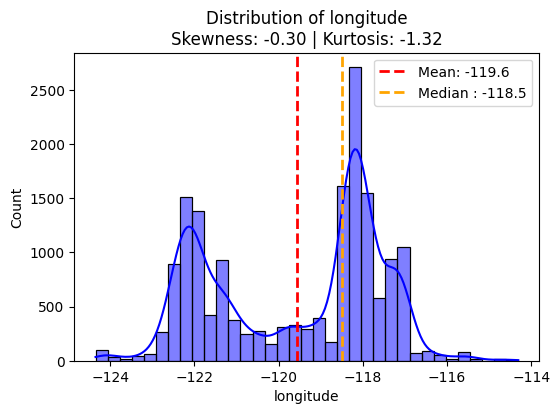

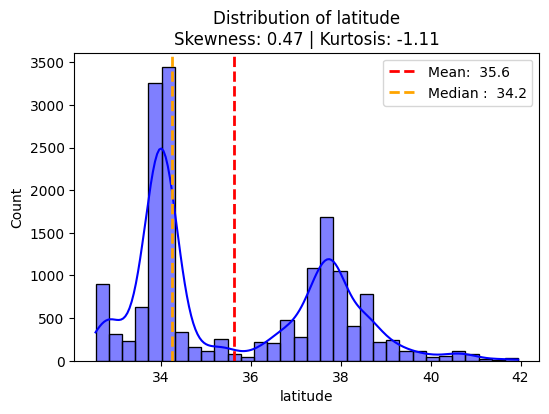

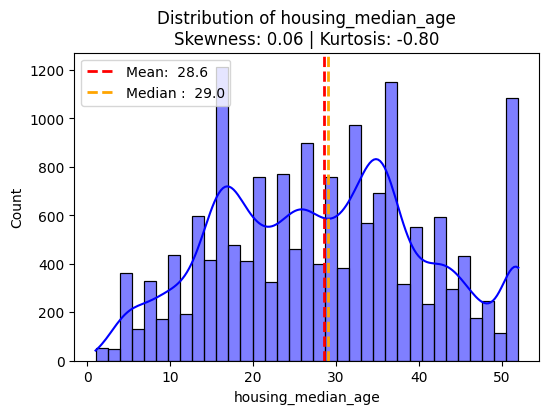

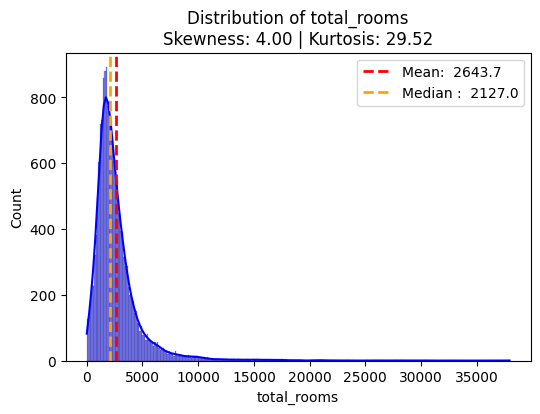

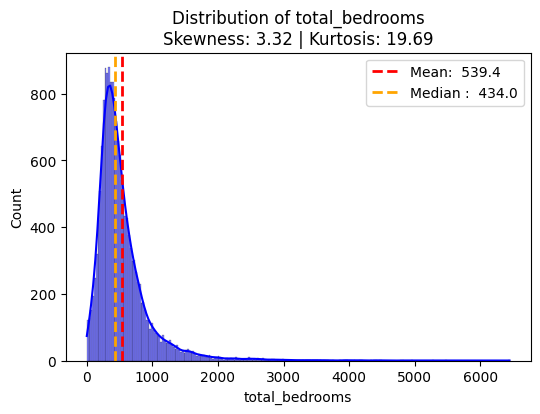

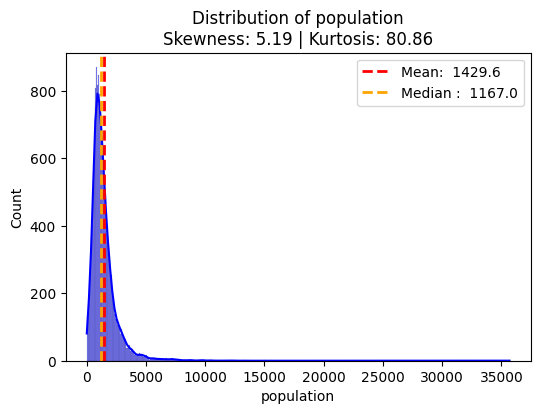

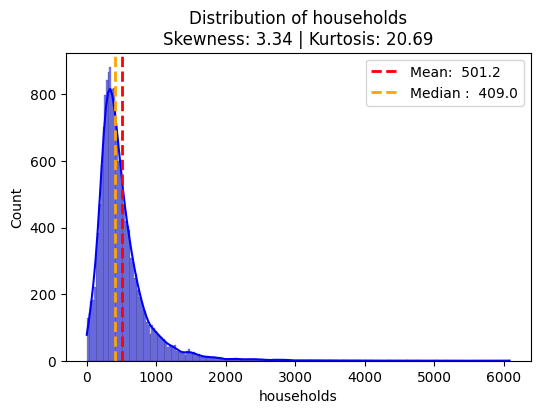

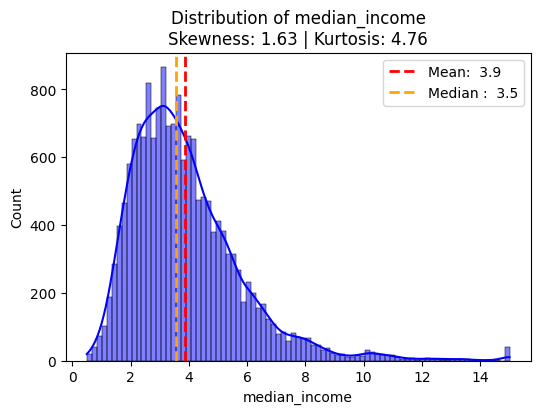

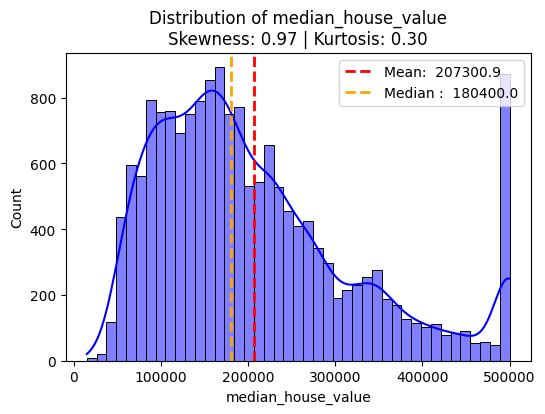





--- Performing IQR Cleaning ---
Original rows: 17000
Rows after IQR cleaning: 14476
Total outliers removed: 2524

--- Cleaned DataFrame (IQR) Summary ---

Statistical Summary Report:


,Feature,Mean,Median,Std_dev,Skewness,Kurtosis,IQR Outliers,Z Outliers
0,longitude,-119.60,-118.58,2.01,-0.27,-1.31,0,0
1,latitude,35.69,34.29,2.17,0.43,-1.13,0,0
2,housing_median_age,29.45,30.00,12.22,0.01,-0.79,0,0
3,total_rooms,2147.54,1979.00,1085.46,0.67,0.24,285,81
4,total_bedrooms,445.66,411.00,220.67,0.65,0.14,228,59
5,population,1197.76,1112.00,600.68,0.63,0.15,253,60
6,households,417.05,387.00,205.08,0.60,0.12,236,53
7,median_income,3.58,3.40,1.45,0.57,-0.10,136,27
8,median_house_value,187286.51,170000.00,94255.02,0.77,0.07,216,44



--- Plotting Cleaned DataFrame ---


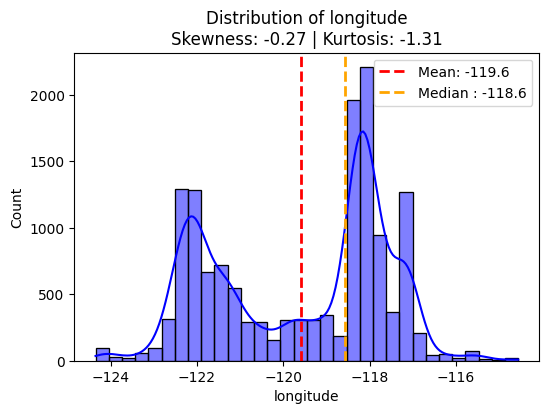

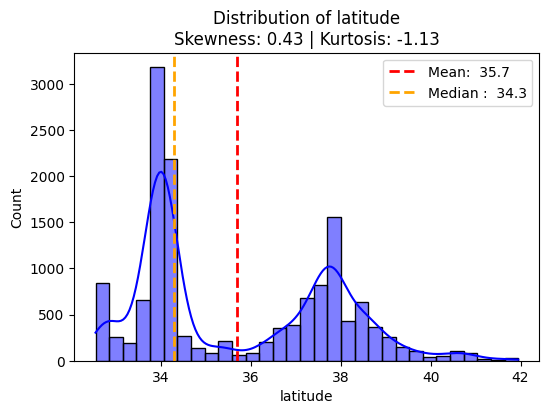

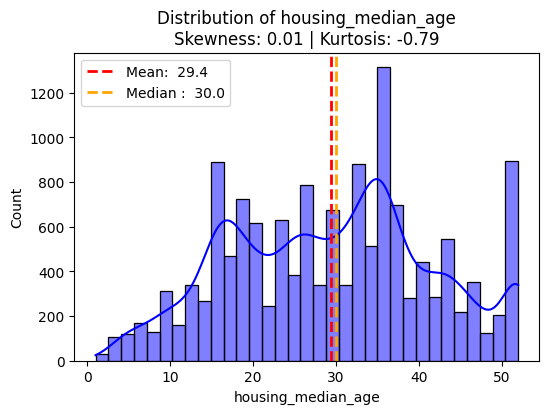

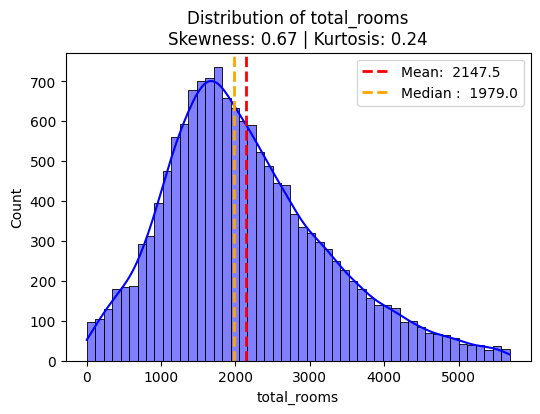

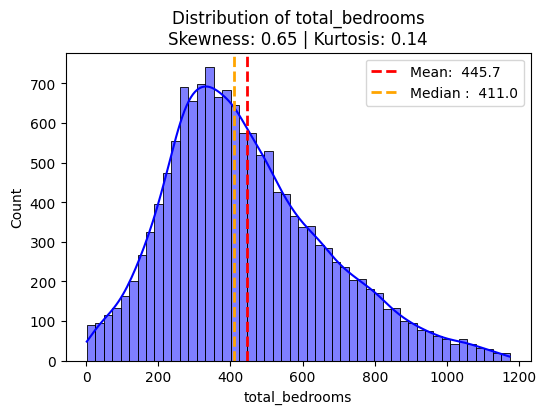

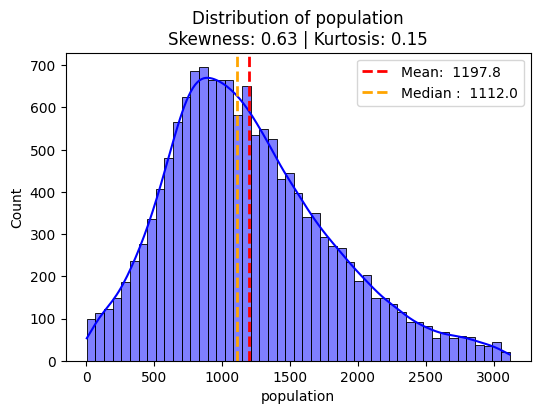

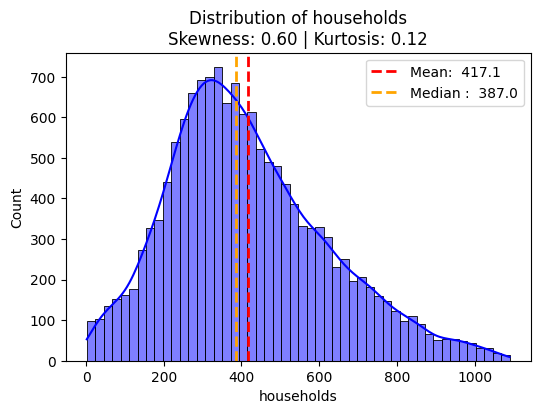

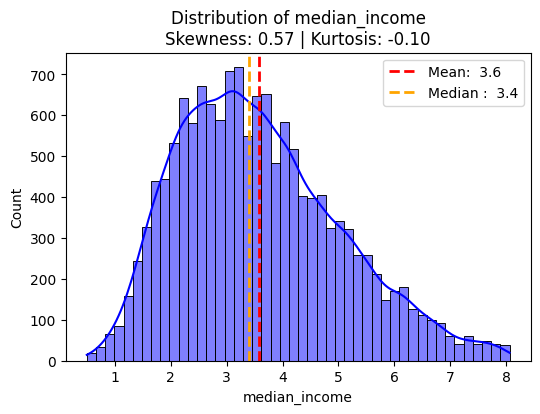

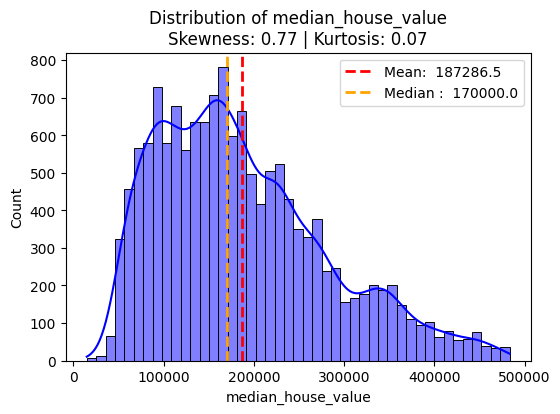





--- Exporting Final Cleaned Report ---
Generating plots for report. Please wait...
Success! Report with 9 automatic plots saved as California_Housing_Cleaned_Report.html


In [64]:
# 1. Load the real-world dataset
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

# 2. Initialize the tool
obj = AutomatedEDA(df)

# 3. Analyze the RAW data
print("\n--- Original DataFrame Summary ---")
raw_summary = obj.generate_summary()

print("\n--- Plotting Original DataFrame ---")
obj.plot()

# 4. Clean the data
print("\n--- Performing IQR Cleaning ---")
cleaned_df_iqr = obj.IQR_cleaning()
print(f"Original rows: {len(df)}")
print(f"Rows after IQR cleaning: {len(cleaned_df_iqr)}")
print(f"Total outliers removed: {len(df) - len(cleaned_df_iqr)}")

# 5. Analyze the CLEANED data
print("\n--- Cleaned DataFrame (IQR) Summary ---")
cleaned_summary = obj.generate_summary(cleaned_df_iqr)

print("\n--- Plotting Cleaned DataFrame ---")
obj.plot(cleaned_df_iqr)

# 6. Optional: Export the cleaned report to HTML!
print("\n--- Exporting Final Cleaned Report ---")
obj.export_report(cleaned_summary, filename="California_Housing_Cleaned_Report")

In [ ]:
df = pd.read_csv("/content/sample_data/mnist_train_small.csv")

obj = AutomatedEDA(df)

# Generate summary for the original DataFrame
print("--- Original DataFrame Summary ---")
obj.generate_summary()

# Optionally, plot distributions for the original DataFrame
obj.plot()

# Perform IQR cleaning
print("\n--- Performing IQR Cleaning ---")
cleaned_df_iqr = obj.IQR_cleaning()
print(f"Original rows: {len(df)}, Rows after IQR cleaning: {len(cleaned_df_iqr)}")

# Generate summary for the DataFrame after IQR cleaning
print("\n--- Cleaned DataFrame (IQR) Summary ---")
obj.generate_summary(cleaned_df_iqr)

# Optionally, plot distributions for the cleaned DataFrame
obj.plot(cleaned_df_iqr)

Example 2

--- Original DataFrame Summary ---

Statistical Summary Report:


,Feature,Mean,Median,Std_dev,Skewness,Kurtosis,IQR Outliers,Z Outliers
0,longitude,-119.56,-118.49,2.01,-0.30,-1.32,0,0
1,latitude,35.63,34.25,2.14,0.47,-1.11,0,0
2,housing_median_age,28.59,29.00,12.59,0.06,-0.80,0,0
3,total_rooms,2643.66,2127.00,2179.95,4.00,29.52,1076,313
4,total_bedrooms,539.41,434.00,421.50,3.32,19.69,1074,312
5,population,1429.57,1167.00,1147.85,5.19,80.86,1015,285
6,households,501.22,409.00,384.52,3.34,20.69,1032,302
7,median_income,3.88,3.54,1.91,1.63,4.76,563,286
8,median_house_value,207300.91,180400.00,115983.76,0.97,0.30,895,0



--- Performing  Z score Cleaning ---
Original rows: 17000, Rows after Z score cleaning: 17000

--- Cleaned DataFrame ( Z-score ) Summary ---

Statistical Summary Report:


,Feature,Mean,Median,Std_dev,Skewness,Kurtosis,IQR Outliers,Z Outliers
0,longitude,-119.56,-118.49,2.01,-0.30,-1.32,0,0
1,latitude,35.63,34.25,2.14,0.47,-1.11,0,0
2,housing_median_age,28.59,29.00,12.59,0.06,-0.80,0,0
3,total_rooms,2643.66,2127.00,2179.95,4.00,29.52,1076,313
4,total_bedrooms,539.41,434.00,421.50,3.32,19.69,1074,312
5,population,1429.57,1167.00,1147.85,5.19,80.86,1015,285
6,households,501.22,409.00,384.52,3.34,20.69,1032,302
7,median_income,3.88,3.54,1.91,1.63,4.76,563,286
8,median_house_value,207300.91,180400.00,115983.76,0.97,0.30,895,0


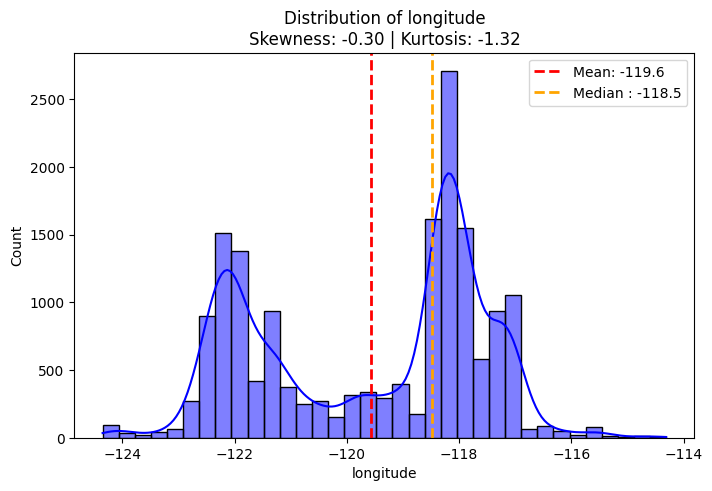

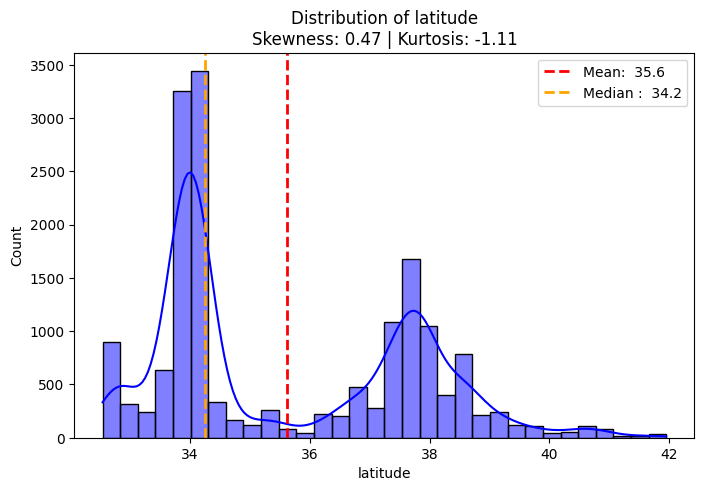

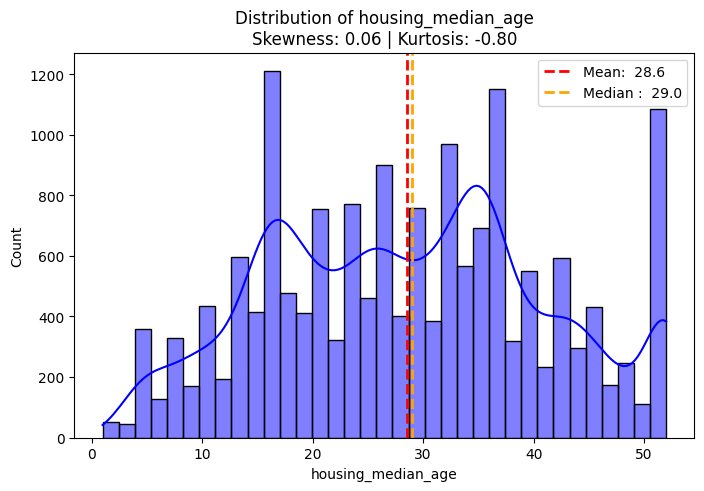

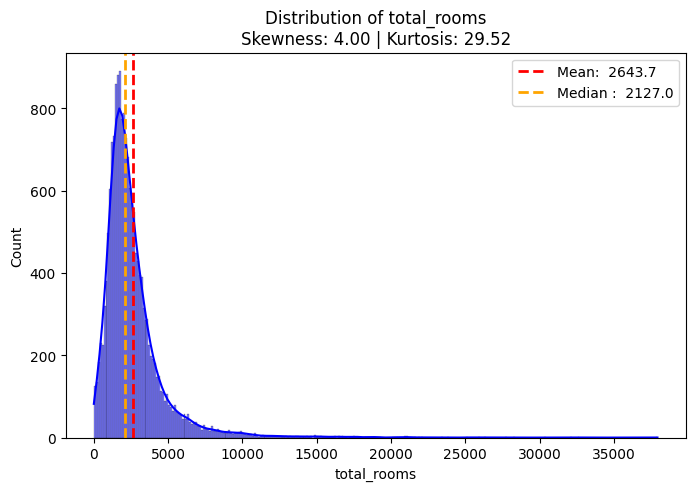

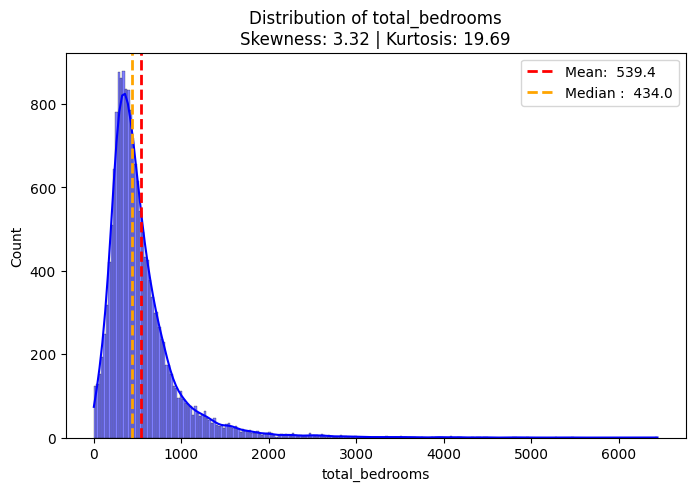

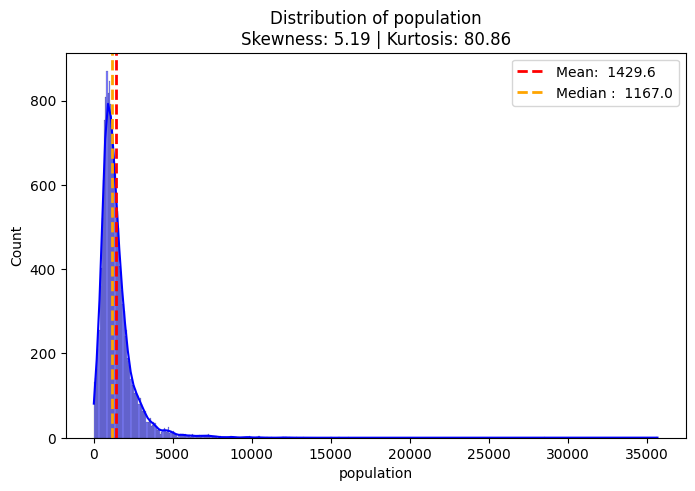

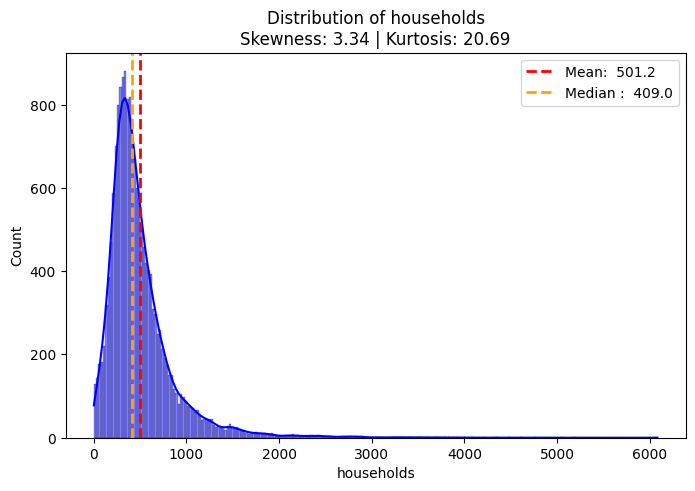

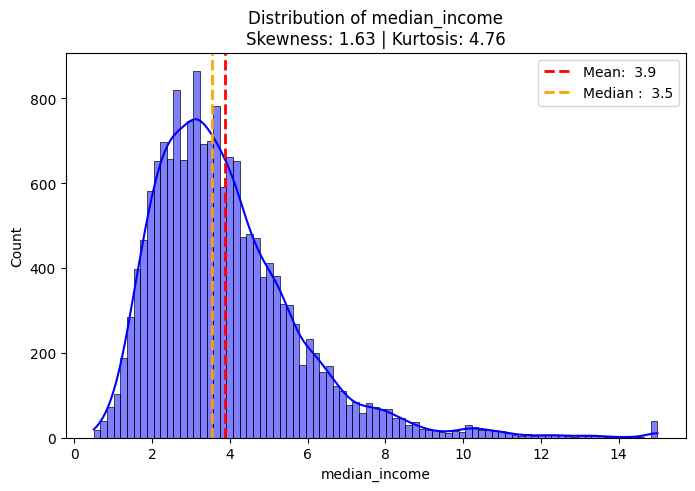

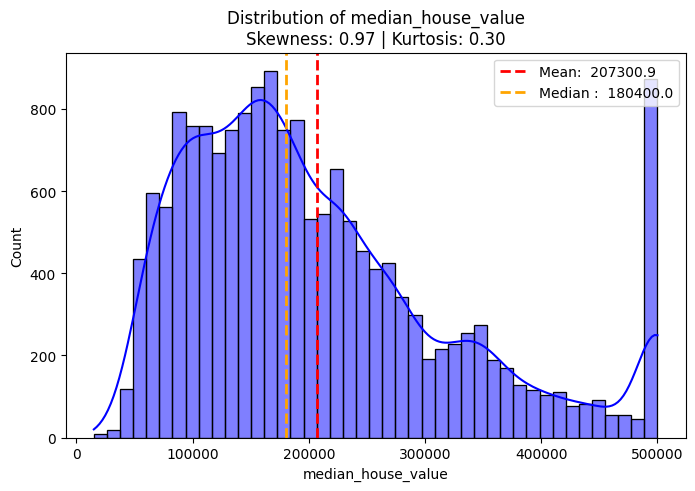

In [59]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

obj = AutomatedEDA(df)

# Generate summary for the original DataFrame
print("--- Original DataFrame Summary ---")
obj.generate_summary()

# Perform Z score cleaning
print("\n--- Performing  Z score Cleaning ---")
cleaned_df_zscore = obj.Z_score_cleanning()
print(f"Original rows: {len(df)}, Rows after Z score cleaning: {len(cleaned_df_zscore)}")

# Generate summary for the DataFrame after  Z-score cleaning
print("\n--- Cleaned DataFrame ( Z-score ) Summary ---")
obj.generate_summary(cleaned_df_zscore)

# Optionally, plot distributions for the cleaned DataFrame
obj.plot(cleaned_df_zscore)

--- Original Input Data ---


,Department,Age,Salary,Experience_Years
0,IT,25,55000,2
1,HR,28,62000,4
2,IT,32,58000,6
3,Sales,29,60000,3
4,Sales,31,65000,5
5,HR,85,59000,40
6,IT,27,250000,3




EDA Object initialized successfully!

--- Generating Summary ---

Statistical Summary Report:


,Feature,Mean,Median,Std_dev,Skewness,Kurtosis,IQR Outliers,Z Outliers
0,Age,36.71,29.0,21.42,2.58,6.73,1,0
1,Salary,87000.00,60000.0,71944.42,2.64,6.96,1,0
2,Experience_Years,9.00,4.0,13.74,2.59,6.79,1,0



--- Generating Plots ---


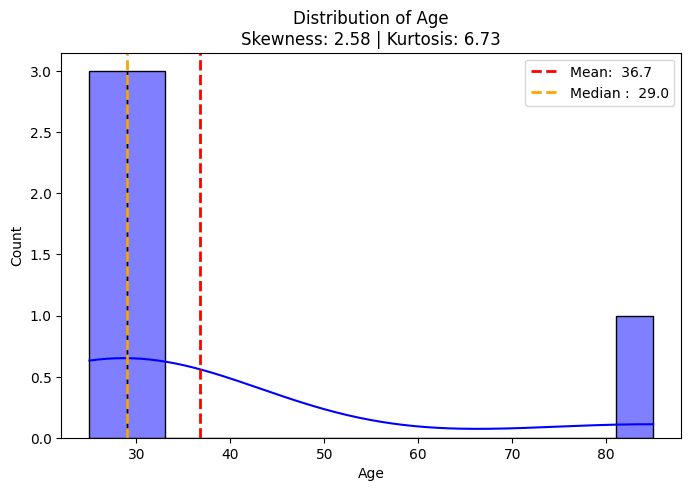

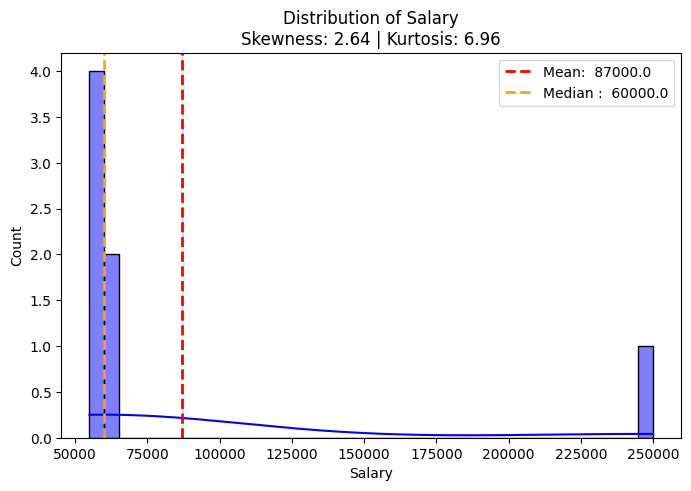

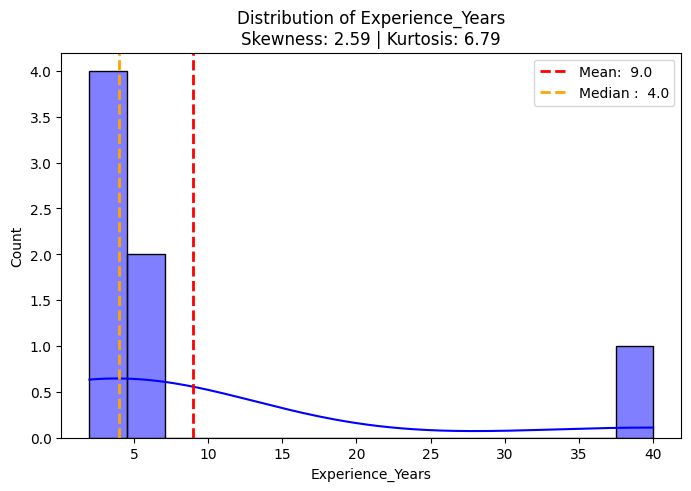





--- Testing Data Cleaning (IQR Method) ---
Original row count: 7
Cleaned row count: 5
Cleaned DataFrame (Notice the outliers are gone!):


,Department,Age,Salary,Experience_Years
0,IT,25,55000,2
1,HR,28,62000,4
2,IT,32,58000,6
3,Sales,29,60000,3
4,Sales,31,65000,5



--- Exporting Report ---
Success! HTML Report saved as My_HR_Report.html


In [61]:
import pandas as pd

# 1. Create the Input DataFrame (Your Raw Data)
data = {
    'Department': ['IT', 'HR', 'IT', 'Sales', 'Sales', 'HR', 'IT'],  # Text column (ignored)
    'Age': [25, 28, 32, 29, 31, 85, 27],                             # 85 is an outlier
    'Salary': [55000, 62000, 58000, 60000, 65000, 59000, 250000],    # 250k is an outlier
    'Experience_Years': [2, 4, 6, 3, 5, 40, 3]                       # 40 is an outlier
}
my_input_df = pd.DataFrame(data)

print("--- Original Input Data ---")
display(my_input_df)
print("\n" + "="*50 + "\n")


# 2. Instantiate your class with the input data
# (This automatically triggers the __init__ method)
eda_tool = AutomatedEDA(my_input_df)

# 3. Generate the statistical summary report
print("\n--- Generating Summary ---")
final_summary = eda_tool.generate_summary()

# 4. Plot the histograms with mean/median lines
print("\n--- Generating Plots ---")
eda_tool.plot()

# 5. Test the Data Cleaning (Removing the outliers)
print("\n--- Testing Data Cleaning (IQR Method) ---")
cleaned_data = eda_tool.IQR_cleaning()

# Show how many rows were dropped
print(f"Original row count: {len(my_input_df)}")
print(f"Cleaned row count: {len(cleaned_data)}")
print("Cleaned DataFrame (Notice the outliers are gone!):")
display(cleaned_data)

# 6. Export the final report to HTML
print("\n--- Exporting Report ---")
eda_tool.export_report(summary_df=final_summary, filename="My_HR_Report")